In [3]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device ="cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
%pip install diffusers
from diffusers import StableDiffusionPipeline

Note: you may need to restart the kernel to use updated packages.


In [5]:
pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype = torch.float16, variant = "fp16"
).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

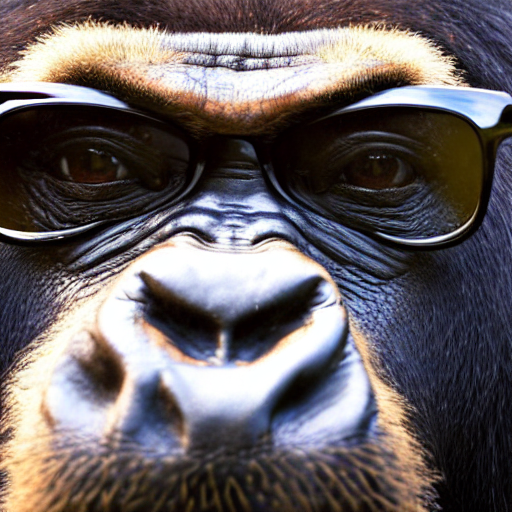

In [14]:
prompt = "a photograph of a gorilla wearing sunglasses"
pipe(prompt).images[0]

In [22]:
from transformers import pipeline
# Clasificación de sentimiento
classifier = pipeline("text-classification", device=device)
classifier("Quiero con tu amiga")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'label': 'NEGATIVE', 'score': 0.5094971060752869}]

In [23]:
generator = pipeline("text-generation", device=device)
generator("I dated a girl that was too short")[0]["generated_text"]


No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


'I dated a girl that was too short, I dated an 11 or 12 year old in a different community. They\'d also dated other people at the same time."\n\n"If I look at some of the stories of bullying, one\'s just'